# Notebook 5 — The Dispatch Engine

This notebook walks through the heart of the simulator: `dispatch_year()`, which dispatches the generator fleet across 35,040 quarter-hours.

Topics:
1. **Phase 1: Merit-order dispatch** (vectorized) — stack generators by SRMC
2. **Phase 2: Inertia fix** (iterative) — enforce H_min = 3.5 seconds
3. Curtailment — when and why renewables get cut
4. Comparing summer vs winter dispatch patterns

Phases 3-4 (exports, storage) are covered in dedicated notebooks.

**Runtime**: < 30 seconds

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from energy_sim.models import TimeGrid, LoadProfile
from energy_sim.generators import build_generators, CarbonPriceModel
from energy_sim.dispatch import dispatch_year
from energy_sim.config import (
    ITALIAN_MIX, GAS_SCENARIOS, P_PEAK_GW,
    QUARTERS_PER_DAY, H_MIN_SECONDS,
    WEEKDAY_LOAD_FACTORS, HOLIDAY_LOAD_FACTOR, ITALIAN_HOLIDAYS_DOY,
    DEFAULT_LOAD_NOISE_SIGMA,
)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Running a single-year dispatch

Let's set up the full pipeline: TimeGrid → LoadProfile → Generators → dispatch.

In [2]:
tg = TimeGrid()
tg.set_holiday_calendar(ITALIAN_HOLIDAYS_DOY)

lp = LoadProfile(tg)
lp.set_weekday_factors(WEEKDAY_LOAD_FACTORS)
lp.set_holiday_factor(HOLIDAY_LOAD_FACTOR)

rng = np.random.default_rng(42)
co2 = CarbonPriceModel()

gens = build_generators(ITALIAN_MIX, GAS_SCENARIOS['base'])
for g in gens:
    g.prepare_run(tg, rng, co2)

load = lp.generate(rng, noise_sigma=DEFAULT_LOAD_NOISE_SIGMA)

# Run dispatch (no interconnections, no storage)
result = dispatch_year(gens, load)

print(f"Dispatch complete!")
print(f"  Average electricity price: {result.marginal_price.mean():.1f} EUR/MWh")
print(f"  Average system inertia:    {result.h_system.mean():.2f} s")
print(f"  Total curtailment:         {result.curtailment.sum() * P_PEAK_GW * 0.25:.0f} GWh")
print(f"  Total unserved energy:     {result.unserved.sum() * P_PEAK_GW * 0.25:.0f} GWh")

Dispatch complete!
  Average electricity price: 84.5 EUR/MWh
  Average system inertia:    4.34 s
  Total curtailment:         0 GWh
  Total unserved energy:     383 GWh


## 2. Phase 1: Merit-Order Dispatch

At each timestep, generators are sorted by SRMC. The cheapest available capacity is dispatched first. The most expensive running generator sets the **marginal price**.

### Full-year marginal price

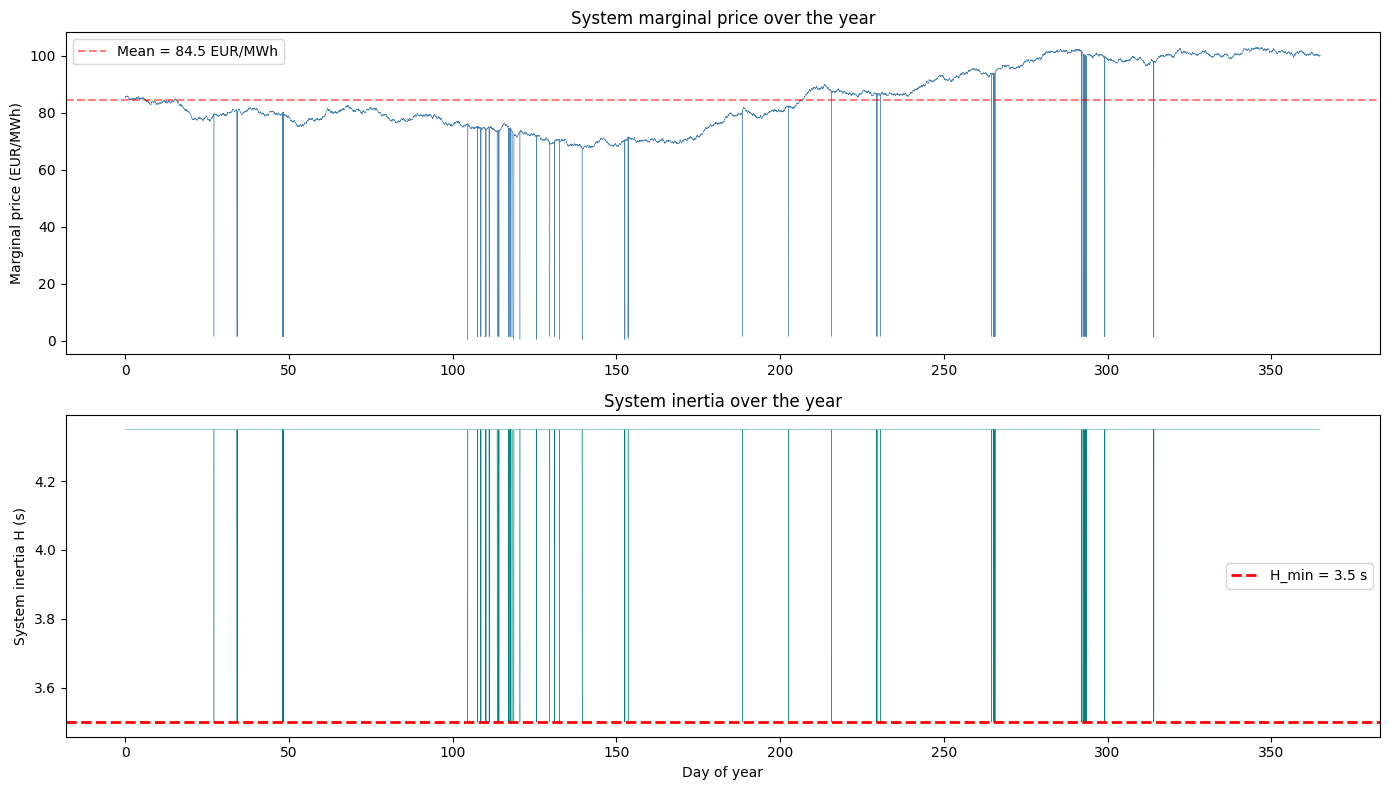

In [3]:
days = np.arange(tg.n) / QUARTERS_PER_DAY

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Marginal price
axes[0].plot(days, result.marginal_price, lw=0.3, color='steelblue')
axes[0].axhline(result.marginal_price.mean(), color='red', ls='--', alpha=0.5,
                label=f'Mean = {result.marginal_price.mean():.1f} EUR/MWh')
axes[0].set_ylabel('Marginal price (EUR/MWh)')
axes[0].set_title('System marginal price over the year')
axes[0].legend()

# System inertia
axes[1].plot(days, result.h_system, lw=0.3, color='teal')
axes[1].axhline(H_MIN_SECONDS, color='red', ls='--', lw=2,
                label=f'H_min = {H_MIN_SECONDS} s')
axes[1].set_ylabel('System inertia H (s)')
axes[1].set_xlabel('Day of year')
axes[1].set_title('System inertia over the year')
axes[1].legend()

plt.tight_layout()
plt.show()

### Dispatch stack: a single day

Let's see what the dispatch looks like hour by hour on a summer day and a winter day:

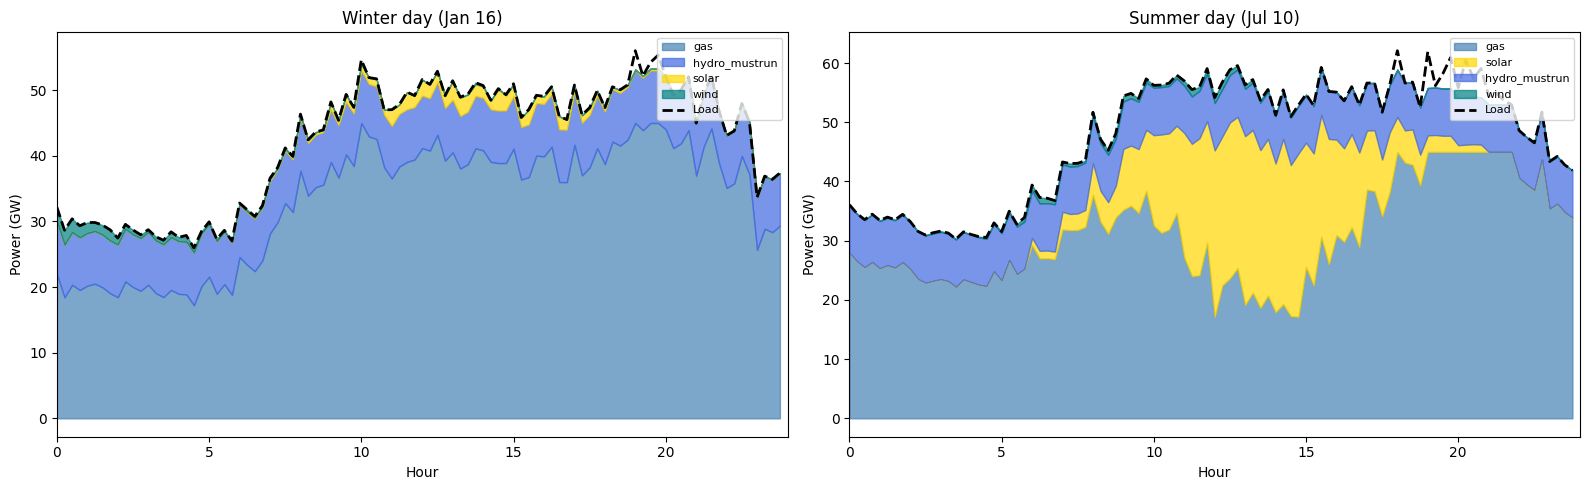

In [4]:
colors_map = {'gas': 'steelblue', 'solar': 'gold', 'wind': 'teal',
              'hydro_mustrun': 'royalblue', 'nuclear': 'purple', 'coal': 'brown'}

def plot_dispatch_day(result, day, title, ax):
    """Plot stacked area dispatch for a single day."""
    start = day * QUARTERS_PER_DAY
    end = start + QUARTERS_PER_DAY
    hours = np.arange(QUARTERS_PER_DAY) / 4
    
    # Sort generators by average SRMC for stacking order
    gen_order = sorted(range(len(result.gen_names)),
                       key=lambda i: result.power[i, start:end].mean(), reverse=True)
    
    bottom = np.zeros(QUARTERS_PER_DAY)
    for i in gen_order:
        power_gw = result.power[i, start:end] * P_PEAK_GW
        name = result.gen_names[i]
        color = colors_map.get(name, 'gray')
        ax.fill_between(hours, bottom, bottom + power_gw,
                        color=color, alpha=0.7, label=name)
        bottom += power_gw
    
    # Load line
    ax.plot(hours, load[start:end] * P_PEAK_GW, 'k--', lw=2, label='Load')
    
    ax.set_xlabel('Hour')
    ax.set_ylabel('Power (GW)')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xlim(0, 24)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_dispatch_day(result, 15, 'Winter day (Jan 16)', axes[0])  # January
plot_dispatch_day(result, 190, 'Summer day (Jul 10)', axes[1])  # July
plt.tight_layout()
plt.show()

## 3. Phase 2: Inertia Constraint

The grid needs a minimum **inertia** $H \geq 3.5$ seconds to remain stable (resist frequency deviations). Only synchronous generators (gas, hydro, nuclear) provide inertia. Renewables (solar, wind) do not.

When renewables push out too many synchronous generators, the cheapest offline synchronous unit is **forced online**, and renewables may be **curtailed** to avoid oversupply.

In [5]:
# Count inertia violations
violations_before = (result.h_system < H_MIN_SECONDS).sum()
curtailed_hours = (result.curtailment > 0).sum()

print(f"Inertia constraint: H_min = {H_MIN_SECONDS} s")
print(f"Timesteps with H below threshold (after fix): {violations_before}")
print(f"Timesteps with curtailment: {curtailed_hours} "
      f"({curtailed_hours / tg.n * 100:.1f}% of year)")
print(f"Total curtailed energy: {result.curtailment.sum() * P_PEAK_GW * 0.25:.1f} GWh")

Inertia constraint: H_min = 3.5 s
Timesteps with H below threshold (after fix): 0
Timesteps with curtailment: 0 (0.0% of year)
Total curtailed energy: 0.0 GWh


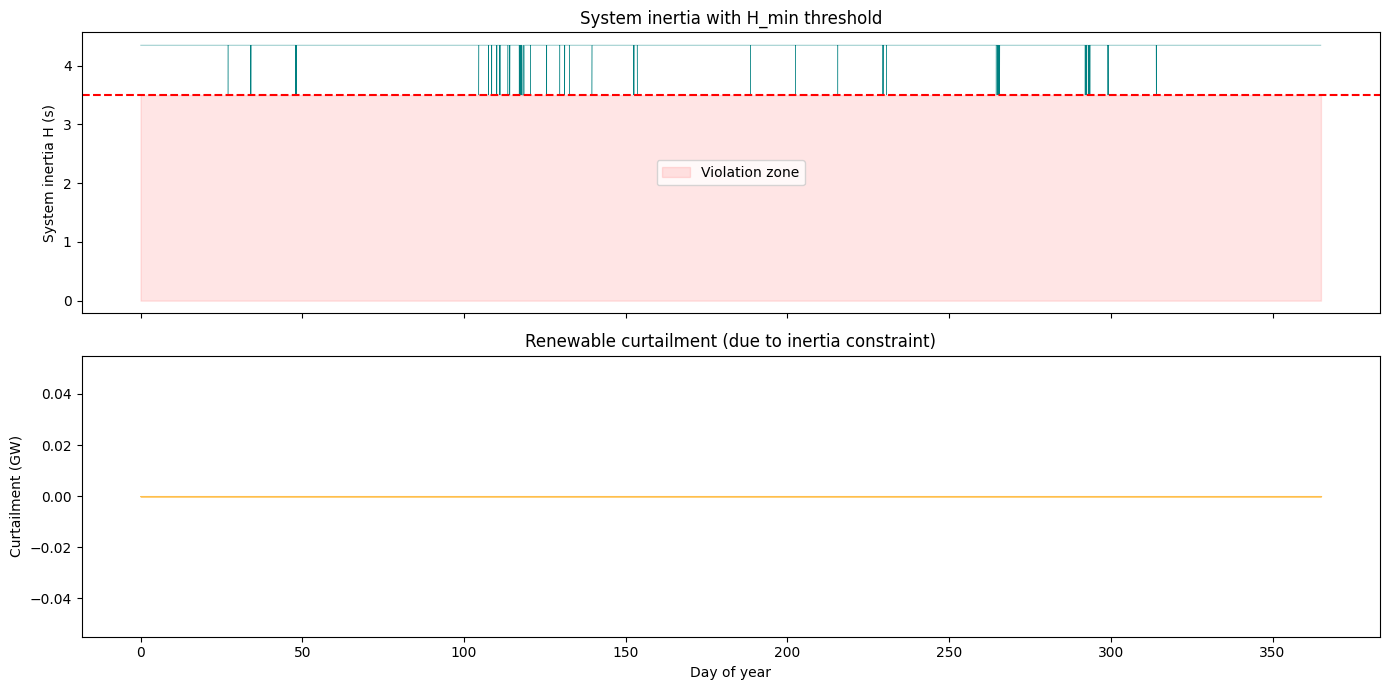

In [6]:
# Visualize inertia and curtailment together
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# H_system with violation highlighting
ax = axes[0]
ax.plot(days, result.h_system, lw=0.3, color='teal')
ax.fill_between(days, 0, H_MIN_SECONDS, alpha=0.1, color='red', label='Violation zone')
ax.axhline(H_MIN_SECONDS, color='red', ls='--', lw=1.5)
ax.set_ylabel('System inertia H (s)')
ax.set_title('System inertia with H_min threshold')
ax.legend()

# Curtailment
ax = axes[1]
ax.fill_between(days, result.curtailment * P_PEAK_GW, color='orange', alpha=0.7)
ax.set_ylabel('Curtailment (GW)')
ax.set_xlabel('Day of year')
ax.set_title('Renewable curtailment (due to inertia constraint)')

plt.tight_layout()
plt.show()

## 4. Price distribution

Let's examine the price distribution — it reveals the typical operating regimes of the system:

/var/folders/tb/rzs9whln4mgg87g3dnb6q0qm0000gn/T/ipykernel_72517/3059410383.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(monthly_prices, labels=month_names, patch_artist=True)


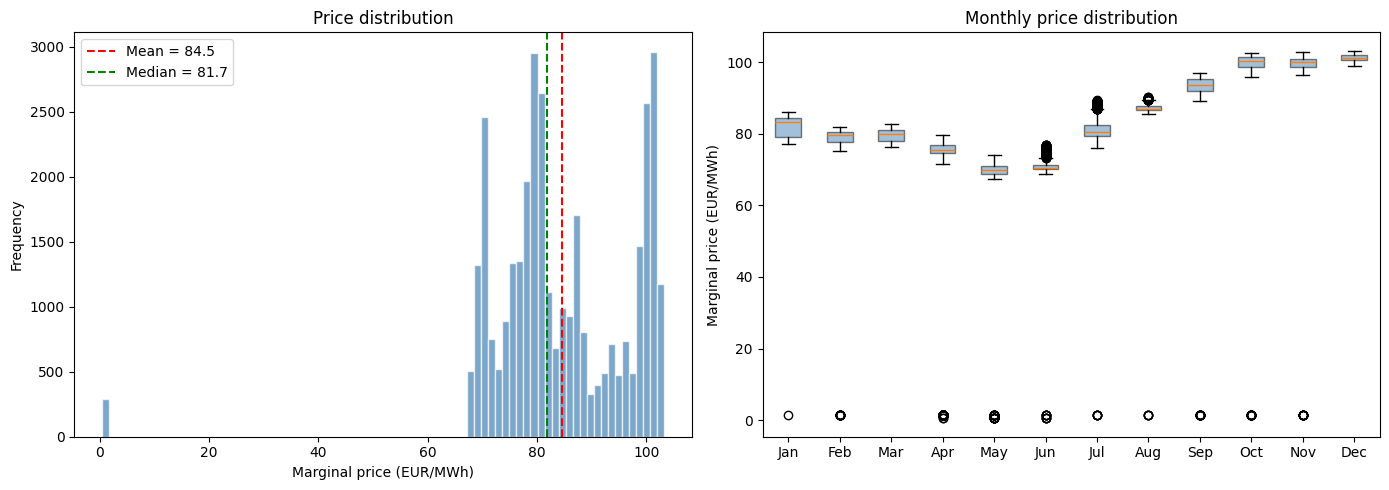

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(result.marginal_price, bins=80, color='steelblue', alpha=0.7,
             edgecolor='white')
axes[0].axvline(result.marginal_price.mean(), color='red', ls='--',
                label=f'Mean = {result.marginal_price.mean():.1f}')
axes[0].axvline(np.median(result.marginal_price), color='green', ls='--',
                label=f'Median = {np.median(result.marginal_price):.1f}')
axes[0].set_xlabel('Marginal price (EUR/MWh)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price distribution')
axes[0].legend()

# Monthly boxplot
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_prices = [result.marginal_price[tg.month == m] for m in range(1, 13)]
bp = axes[1].boxplot(monthly_prices, labels=month_names, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.5)
axes[1].set_ylabel('Marginal price (EUR/MWh)')
axes[1].set_title('Monthly price distribution')

plt.tight_layout()
plt.show()

## 5. Play with renewable penetration

What happens if we double solar capacity?

With +30 GW solar, +0 GW wind:
  Avg price:     78.8 EUR/MWh (was 84.5)
  Avg inertia:   4.28 s (was 4.34)
  Curtailment:   0 GWh (was 0)


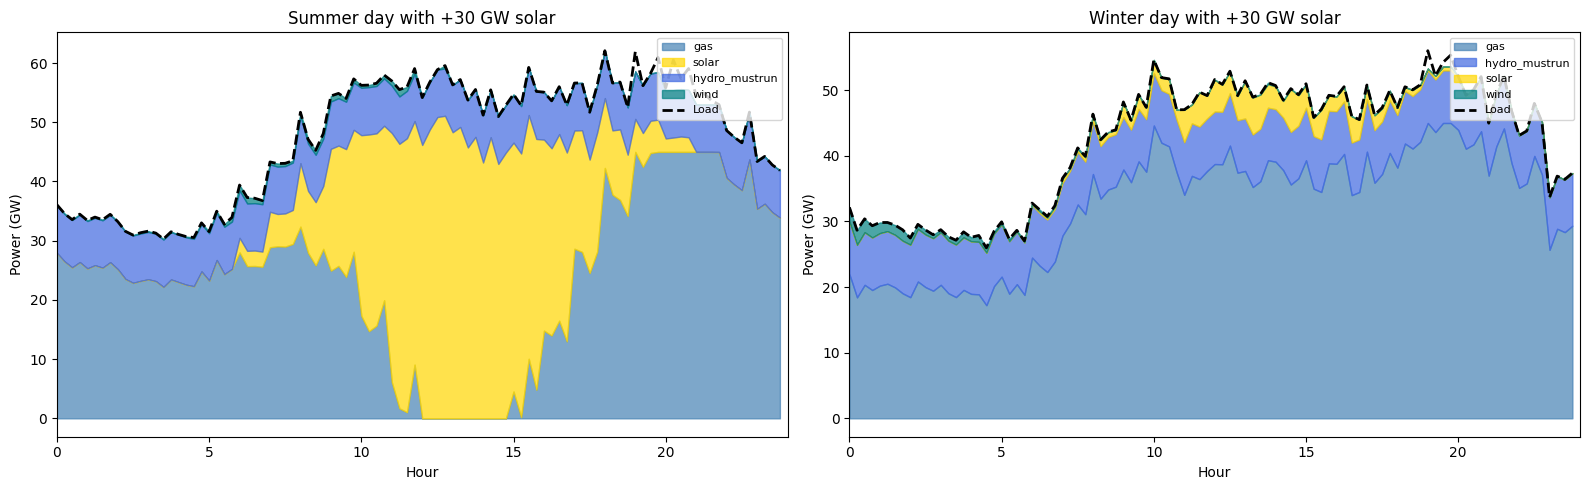

In [8]:
from copy import deepcopy

# ── PLAY WITH THESE ──────────────────────────────────────
extra_solar_gw = 30.0     # try 0, 15, 30, 60
extra_wind_gw = 0.0       # try 0, 10, 20
# ─────────────────────────────────────────────────────────

mix2 = deepcopy(ITALIAN_MIX)
mix2['solar']['capacity_gw'] += extra_solar_gw
mix2['wind']['capacity_gw'] += extra_wind_gw

gens2 = build_generators(mix2, GAS_SCENARIOS['base'])
rng2 = np.random.default_rng(42)
co2_2 = CarbonPriceModel()
for g in gens2:
    g.prepare_run(tg, rng2, co2_2)

load2 = lp.generate(rng2, noise_sigma=DEFAULT_LOAD_NOISE_SIGMA)
result2 = dispatch_year(gens2, load2)

print(f"With +{extra_solar_gw:.0f} GW solar, +{extra_wind_gw:.0f} GW wind:")
print(f"  Avg price:     {result2.marginal_price.mean():.1f} EUR/MWh "
      f"(was {result.marginal_price.mean():.1f})")
print(f"  Avg inertia:   {result2.h_system.mean():.2f} s "
      f"(was {result.h_system.mean():.2f})")
print(f"  Curtailment:   {result2.curtailment.sum() * P_PEAK_GW * 0.25:.0f} GWh "
      f"(was {result.curtailment.sum() * P_PEAK_GW * 0.25:.0f})")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_dispatch_day(result2, 190, f'Summer day with +{extra_solar_gw:.0f} GW solar', axes[0])
plot_dispatch_day(result2, 15, f'Winter day with +{extra_solar_gw:.0f} GW solar', axes[1])
plt.tight_layout()
plt.show()

## Key Takeaways

1. **Merit-order dispatch** is vectorized — sorting 5+ generators across 35,040 timesteps takes ~30ms.
2. The **marginal price** is set by the most expensive running generator. When renewables are abundant, gas barely runs and prices drop.
3. The **inertia constraint** limits how much renewable penetration the grid can absorb without synchronous machines. This is the physical reason why 100% renewables needs storage or synchronous condensers.
4. **Curtailment** is the cost of excess renewable supply — energy that could have been generated but is thrown away because the grid can't absorb it.
5. Summer and winter dispatch are fundamentally different: summer is solar-dominated with daytime price collapses; winter relies on gas + wind.

**Next notebook**: [06 — Monte Carlo & Sensitivity](./06_monte_carlo_and_sensitivity.ipynb) — running many years to get statistical confidence.

1. would be nice a plot like the one above where you see the dynamic evolution of the price in a specific day
2. in the second plot you see there are moment where the load exceeds the generation. Investigate what happens here because it's not acceptable